# Trying out approaches from 

- https://www.semanticscholar.org/reader/2c4f37fdb131a2bb05ee33b11abaab9ed2bfcee7
- https://www.emergentmind.com/papers/2312.10001


In [1]:
from notebooks.experiment.preprocessing import load_and_clean, add_stim_features, check_df
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import os
from tqdm import tqdm
import sklearn
import torch

In [ ]:
exp_paths = [
'/Volumes/imaging.data/PertzLab/optoRTK_CedricZ/experimental_data/2025-11-03_3-2-1minIntervals/', # 660 cells, # 180 min
'/Volumes/imaging.data/PertzLab/optoRTK_CedricZ/experimental_data/2025-10-12_DoseResponse', # 800 cells, 40min
'/Volumes/imaging.data/PertzLab/optoRTK_CedricZ/experimental_data/2025-11-02_Sustained_1min', # 1350 cells, 120 min
'/Volumes/imaging.data/PertzLab/optoRTK_CedricZ/experimental_data/2025-09-04_RampReverse',
]
# load these and process according to the above-defined pipeline, then save as dataset.parquet
dfs = []
for ep in exp_paths:    
    exp = Path(ep)
    p = exp / 'exp_data.parquet' 
    if not p.exists():
        raise FileNotFoundError(f"Data file not found: {p}")

    cell_sel_path = exp / 'cell_selection.csv'
    if cell_sel_path.exists():
        df_i = load_and_clean(p, cell_selection_csv=cell_sel_path)
    else:
        df_i = load_and_clean(p)
    dfs.append(df_i.copy())

df = pd.concat(dfs, ignore_index=True)
df.reset_index(drop=True, inplace=True)

cell line selection for  /Volumes/imaging.data/PertzLab/optoRTK_CedricZ/experimental_data/2025-11-03_3-2-1minIntervals/exp_data.parquet  running...


/Users/polya/workshop/masters/notebooks/experiment/preprocessing.py:96: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['stim_exposure'].fillna(0, inplace=True) # if you're not giving me exposure, it's probably zero


cell line selection for  /Volumes/imaging.data/PertzLab/optoRTK_CedricZ/experimental_data/2025-10-12_DoseResponse/exp_data.parquet  running...


/Users/polya/workshop/masters/notebooks/experiment/preprocessing.py:96: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['stim_exposure'].fillna(0, inplace=True) # if you're not giving me exposure, it's probably zero


cell line selection for  /Volumes/imaging.data/PertzLab/optoRTK_CedricZ/experimental_data/2025-11-02_Sustained_1min/exp_data.parquet  running...


/Users/polya/workshop/masters/notebooks/experiment/preprocessing.py:96: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['stim_exposure'].fillna(0, inplace=True) # if you're not giving me exposure, it's probably zero
/Users/polya/workshop/masters/notebooks/experiment/preprocessing.py:96: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on wh

KeyError: 'cnr_filled'


| Column | Type | Description |
|---|---|---|
| `u_t` | float64 | Raw pulse amplitude (`fluence_mJ_cm2`). Primary input signal. |
| `m_t` | int | Activation indicator: 1 if stimulated, 0 otherwise. Disambiguates rest from zero-amplitude frames. |
| `~~dt_since_pulse~~` | float64 | REPLACED BY `recency` Minutes (frames) since the most recent pulse for this cell. `NaN` before the cell's first pulse. Captures gap dynamics. |
| `recency` | float64 | Saturated recency of a pulse \[0-1] |
| `ewma_fast` | float64 | Exponentially weighted moving average of `u_t` with `alpha=0.5`. Short-term effective stimulation level (equivalent to a discretised first-order ODE with fast decay). |
| `ewma_slow` | float64 | EWMA of `u_t` with `alpha=0.1`. Medium-term accumulation (slow decay). |
| `n_5` | int | Number of pulses (`m_t == 1`) in the last `window_min` frames. Measures burst density. |
| `slope_5` | float64 | OLS slope of `u_t` over the last `window_min` frames. Detects ramp-up / ramp-down patterns. |
| `burst_pos` | int | 1-indexed position within the current consecutive burst of stimulated frames. 0 when the cell is not stimulated. Captures adaptation/facilitation within a burst. |
| `s_cum` | float64 | Cumulative sum of `u_t` up to and including the current frame. Total light exposure history. |


In [ ]:
df.par

In [6]:
df = pd.read_parquet('./dataset.parquet')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497952 entries, 0 to 497951
Data columns (total 54 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   mean_intensity_C0_nuc             497952 non-null  float64
 1   mean_intensity_C1_nuc             497952 non-null  float64
 2   label                             497952 non-null  uint32 
 3   x                                 497952 non-null  float64
 4   y                                 497952 non-null  float64
 5   area                              497952 non-null  float64
 6   median_intensity_C0_nuc           497952 non-null  float64
 7   median_intensity_C1_nuc           497952 non-null  float64
 8   mean_intensity_C0_ring            497952 non-null  float64
 9   mean_intensity_C1_ring            497952 non-null  float64
 10  median_intensity_C0_ring          497952 non-null  float64
 11  median_intensity_C1_ring          497952 non-null  f

# Auguments

Changing the simple pulse encoding into something more machine-friendly.


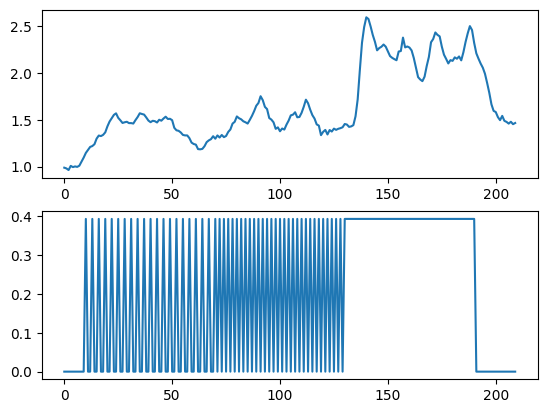

In [40]:
c1 = df[df['uid'] == '3-2-1minIntervals5_24'].sort_values('frame')[['cnr_norm', 'fluence_mJ_cm2']]
x = np.arange(len(c1))

fig, ax = plt.subplots(2)
#ax = np.ravel(ax)
ax[0].plot(x, c1['cnr_norm']) 
ax[1].plot(x, c1['fluence_mJ_cm2']) 

In [4]:
rpu = df['ramp_pattern_name'].unique()

In [54]:
df[df['ramp_pattern_name'] == rpu[i]]['uid'].iloc[0]

'Single36_1'

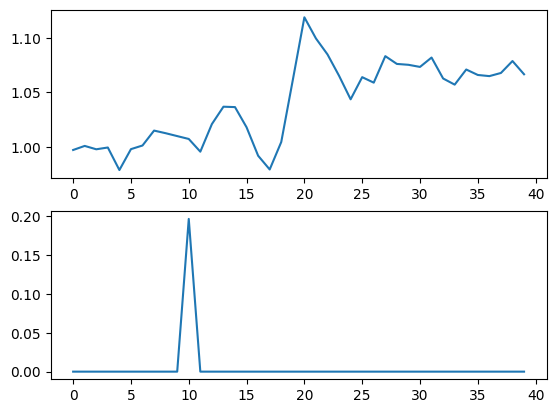

In [55]:
i = 1
uid = df[df['ramp_pattern_name'] == rpu[i]]['uid'].iloc[0]
c1 = df[df['uid'] == uid ].sort_values('frame')[['cnr_norm', 'fluence_mJ_cm2']]
x = np.arange(len(c1))

fig, ax = plt.subplots(2)
#ax = np.ravel(ax)
ax[0].plot(x, c1['cnr_norm']) 
ax[1].plot(x, c1['fluence_mJ_cm2']) 

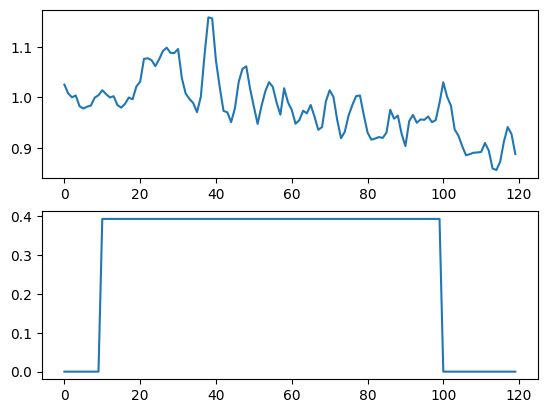

In [58]:
i = 2
uid = df[df['ramp_pattern_name'] == rpu[i]]['uid'].iloc[0]
c1 = df[df['uid'] == uid ].sort_values('frame')[['cnr_norm', 'fluence_mJ_cm2']]
x = np.arange(len(c1))

fig, ax = plt.subplots(2)
#ax = np.ravel(ax)
ax[0].plot(x, c1['cnr_norm']) 
ax[1].plot(x, c1['fluence_mJ_cm2']) 

In [9]:
df.columns[-10:]

Index(['energy_per_cell', 'u_t', 'm_t', 'dt_since_pulse', 'burst_pos', 'n_5',
       'slope_5', 'ewma_fast', 'ewma_slow', 's_cum'],
      dtype='object')

In [ ]:
i = 3
uid = df[df['ramp_pattern_name'] == rpu[i]]['uid'].iloc[0]
c1_a = df[df['uid'] == uid ].sort_values('frame')
c1 = c1_a[['cnr_norm', 'fluence_mJ_cm2']]
c1_m = c1_a[['u_t', 'm_t', 'dt_since_pulse', 'burst_pos', 'n_5','slope_5', 'ewma_fast', 'ewma_slow', 's_cum']]
c1_m.iloc[100:]

,u_t,m_t,dt_since_pulse,burst_pos,n_5,slope_5,ewma_fast,ewma_slow,s_cum
470761,0.814800,1,0.0,92,5,-0.016975,0.831775,0.967566,146.035925
470782,0.797825,1,0.0,93,5,-0.016975,0.814800,0.950592,146.833750
470803,0.780850,1,0.0,94,5,-0.016975,0.797825,0.933617,147.614600
470824,0.763875,1,0.0,95,5,-0.016975,0.780850,0.916643,148.378475
470845,0.746900,1,0.0,96,5,-0.016975,0.763875,0.899669,149.125375
...,...,...,...,...,...,...,...,...,...
472293,NaN,0,26.0,0,0,NaN,0.016975,0.152775,NaN
472314,NaN,0,27.0,0,0,NaN,0.016975,0.152775,NaN
472335,NaN,0,28.0,0,0,NaN,0.016975,0.152775,NaN
472356,NaN,0,29.0,0,0,NaN,0.016975,0.152775,NaN


We find a lot of NaNs here. Not good. Let's get rid of them.

What are the semantics of their existance?


Well, some came from bugs (stim_exposure is NaN, which should not happen)

In [64]:
df[df['frame'] > 100]['stim_exposure'].unique(), 'NAs in stim exp:',df['stim_exposure'].isna().count()

(array([  0., 100., 250., 500.,  50., 245., 240., 235., 230., 225., 220.,
        215., 210., 205., 200., 195., 190., 185., 180., 175., 170., 165.,
        160., 155., 150., 145., 140., 135., 130., 125., 120., 115., 110.,
        105.,  95.,  90.,  85.,  80.,  75.,  70.,  65.,  60.,  55.,  45.,
         40.,  35.,  30.,  25.,  20.,  15.,  10.,   5.,  nan],
       dtype=float32),
 'NAs in stim exp:',
 np.int64(497952))

Let's plot them

individual cells: 257 out of 4202 contaminated,  10019 data points in total (out of 497952 )
Data points lost if filtered cells: 46236 about 9.285232311548102 %


<Axes: >

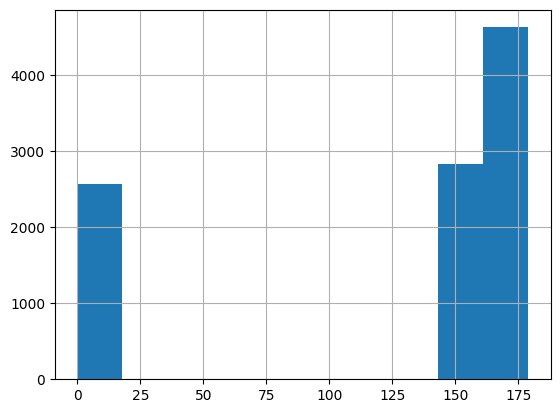

In [ ]:
suspect = df[df['stim_exposure'].isna()]
print('individual cells:',suspect['uid'].unique().__len__(), 'out of', df['uid'].unique().__len__(), 'contaminated, ', len(suspect), 'data points in total (out of', len(df) , ')')
sus_cell_uid = suspect['uid'].unique()
total_sus = df[df['uid'].isin(sus_cell_uid)]
print('Data points lost if filtered cells:', len(total_sus), 'about',(len(total_sus)/len(df) * 100), '%' )
suspect['frame'].hist() 

In [70]:
total_sus.groupby('ramp_pattern_name').count()

,mean_intensity_C0_nuc,mean_intensity_C1_nuc,label,x,y,area,median_intensity_C0_nuc,median_intensity_C1_nuc,mean_intensity_C0_ring,mean_intensity_C1_ring,...,energy_per_cell,u_t,m_t,dt_since_pulse,burst_pos,n_5,slope_5,ewma_fast,ewma_slow,s_cum
ramp_pattern_name,,,,,,,,,,,,,,,,,,,,,
ramp1,46236,46236,46236,46236,46236,46236,46236,46236,46236,46236,...,36217,36217,46236,43668,46236,46236,35446,43668,43668,36217


In [73]:
cleaned = df.drop(total_sus.index)
cleaned[cleaned['ramp_pattern_name'] == 'ramp1']


,mean_intensity_C0_nuc,mean_intensity_C1_nuc,label,x,y,area,median_intensity_C0_nuc,median_intensity_C1_nuc,mean_intensity_C0_ring,mean_intensity_C1_ring,...,energy_per_cell,u_t,m_t,dt_since_pulse,burst_pos,n_5,slope_5,ewma_fast,ewma_slow,s_cum


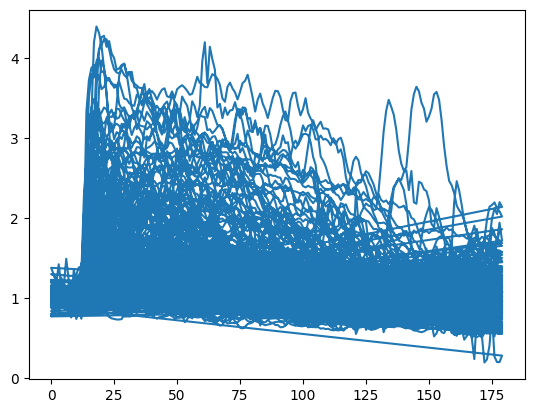

In [ ]:
n = df[df['ramp_pattern_name']=='ramp1']['stim_exposure'].fillna(0)
df_filled = df.copy()
df_filled['cnr_filled'] = n

x = df_filled[df_filled['ramp_pattern_name'] == 'ramp1']

plt.plot(x['frame'], x['cnr_filled'])

In [79]:
n = add_stim_features(df_filled)
n.info()

<class 'pandas.core.frame.DataFrame'>
Index: 497952 entries, 6930 to 468615
Data columns (total 55 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   mean_intensity_C0_nuc             497952 non-null  float64
 1   mean_intensity_C1_nuc             497952 non-null  float64
 2   label                             497952 non-null  uint32 
 3   x                                 497952 non-null  float64
 4   y                                 497952 non-null  float64
 5   area                              497952 non-null  float64
 6   median_intensity_C0_nuc           497952 non-null  float64
 7   median_intensity_C1_nuc           497952 non-null  float64
 8   mean_intensity_C0_ring            497952 non-null  float64
 9   mean_intensity_C1_ring            497952 non-null  float64
 10  median_intensity_C0_ring          497952 non-null  float64
 11  median_intensity_C1_ring          497952 non-null  flo

In [84]:
for c in 'burst_pos	n_5	slope_5	ewma_fast	ewma_slow	s_cum	cnr_filled'.split():
  assert df[c].notna().all(), c

AssertionError: slope_5

In [85]:
df['slope_5']

6930      0.0
6997      0.0
7064      0.0
7131      0.0
7198      0.0
         ... 
468543    NaN
468561    NaN
468579    NaN
468597    NaN
468615    NaN
Name: slope_5, Length: 497952, dtype: float64

In [ ]:
fig, ax = plt.subplots(2)
#ax = np.ravel(ax)
ax[0].plot(x, c1['cnr_norm']) 
ax[1].plot(x, c1['fluence_mJ_cm2']) 

In [ ]:
df.loc[472335]['stim_exposure']

np.float32(nan)

Now for the hard part; 